In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# 선수 데이터 불러오기
park = pd.read_csv('../data/park_statcast.csv')
kim = pd.read_csv('../data/kim_statcast.csv')
choo = pd.read_csv('../data/choo_statcast.csv')

print(f"박찬호: {len(park)} 투구 (2008-2010)")
print(f"김병현: {len(kim)} 투구 (2007)")
print(f"추신수: {len(choo)} 타석 (2008-2020)")

박찬호: 4619 투구 (2008-2010)
김병현: 2298 투구 (2007)
추신수: 29849 타석 (2008-2020)


/var/folders/sc/x7fdp9gs2b3fbn2n56ssf8f40000gn/T/ipykernel_2435/1771113367.py:10: DtypeWarning: Columns (85,86) have mixed types. Specify dtype option on import or set low_memory=False.
  choo = pd.read_csv('../data/choo_statcast.csv')


In [2]:
# 박찬호의 구종 분포 확인
print("=== 박찬호 구종 분포 ===")
print(park['pitch_type'].value_counts())
print(f"\n평균 패스트볼 구속: {park[park['pitch_type'].isin(['FF', 'FT'])]['release_speed'].mean():.1f} mph")

=== 박찬호 구종 분포 ===
pitch_type
SL    1362
SI    1105
FF     884
CU     431
CH     419
IN      40
PO       4
FA       2
Name: count, dtype: int64

평균 패스트볼 구속: 92.6 mph


In [3]:
# 박찬호 구종별 평균 구속
park_pitch_speed = park.groupby('pitch_type')['release_speed'].agg(['mean', 'count'])
park_pitch_speed = park_pitch_speed[park_pitch_speed['count'] >= 20]  # 20개 이상 던진 구종만
park_pitch_speed = park_pitch_speed.sort_values('mean', ascending=False)
print("=== 박찬호 구종별 평균 구속 (20개 이상) ===")
print(park_pitch_speed.round(1))

=== 박찬호 구종별 평균 구속 (20개 이상) ===
            mean  count
pitch_type             
FF          92.6    884
SI          92.3   1105
SL          85.4   1362
CH          84.4    419
CU          77.6    431
IN          62.5     40


In [4]:
# 김병현 구종 분포
print("=== 김병현 구종 분포 ===")
print(kim['pitch_type'].value_counts())
print(f"\n평균 패스트볼 구속: {kim[kim['pitch_type'].isin(['FF', 'FT'])]['release_speed'].mean():.1f} mph")

# 김병현 구종별 평균 구속
kim_pitch_speed = kim.groupby('pitch_type')['release_speed'].agg(['mean', 'count'])
kim_pitch_speed = kim_pitch_speed[kim_pitch_speed['count'] >= 20]
kim_pitch_speed = kim_pitch_speed.sort_values('mean', ascending=False)
print("\n=== 김병현 구종별 평균 구속 (20개 이상) ===")
print(kim_pitch_speed.round(1))

=== 김병현 구종 분포 ===
pitch_type
FA    338
CH     83
SL     78
CU     10
PO      4
Name: count, dtype: int64

평균 패스트볼 구속: nan mph

=== 김병현 구종별 평균 구속 (20개 이상) ===
Empty DataFrame
Columns: [mean, count]
Index: []


In [5]:
# 추신수 시즌별 주요 지표 (Statcast에서 추출 가능한 것들)
# game_date로 시즌 구분
choo['season'] = pd.to_datetime(choo['game_date']).dt.year

# 시즌별 타석 수
choo_by_season = choo.groupby('season').agg(
    plate_appearances=('game_date', 'count'),
    avg_launch_speed=('launch_speed', 'mean'),
    avg_launch_angle=('launch_angle', 'mean')
).round(1)

print("=== 추신수 시즌별 Statcast 요약 ===")
print(choo_by_season)

=== 추신수 시즌별 Statcast 요약 ===
        plate_appearances  avg_launch_speed  avg_launch_angle
season                                                       
2008                 1418               NaN               NaN
2009                 2836               NaN               NaN
2010                 2667               NaN               NaN
2011                 1518               NaN               NaN
2012                 2994               NaN               NaN
2013                 3125               NaN               NaN
2014                 2361               NaN               NaN
2015                 2861              89.0               8.9
2016                 1023              87.1              13.9
2017                 2744              83.9              13.0
2018                 2885              84.3              12.5
2019                 2830              86.1              14.0
2020                  587              84.0              12.8


/var/folders/sc/x7fdp9gs2b3fbn2n56ssf8f40000gn/T/ipykernel_2435/2545279027.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=9)


차트 저장 완료!


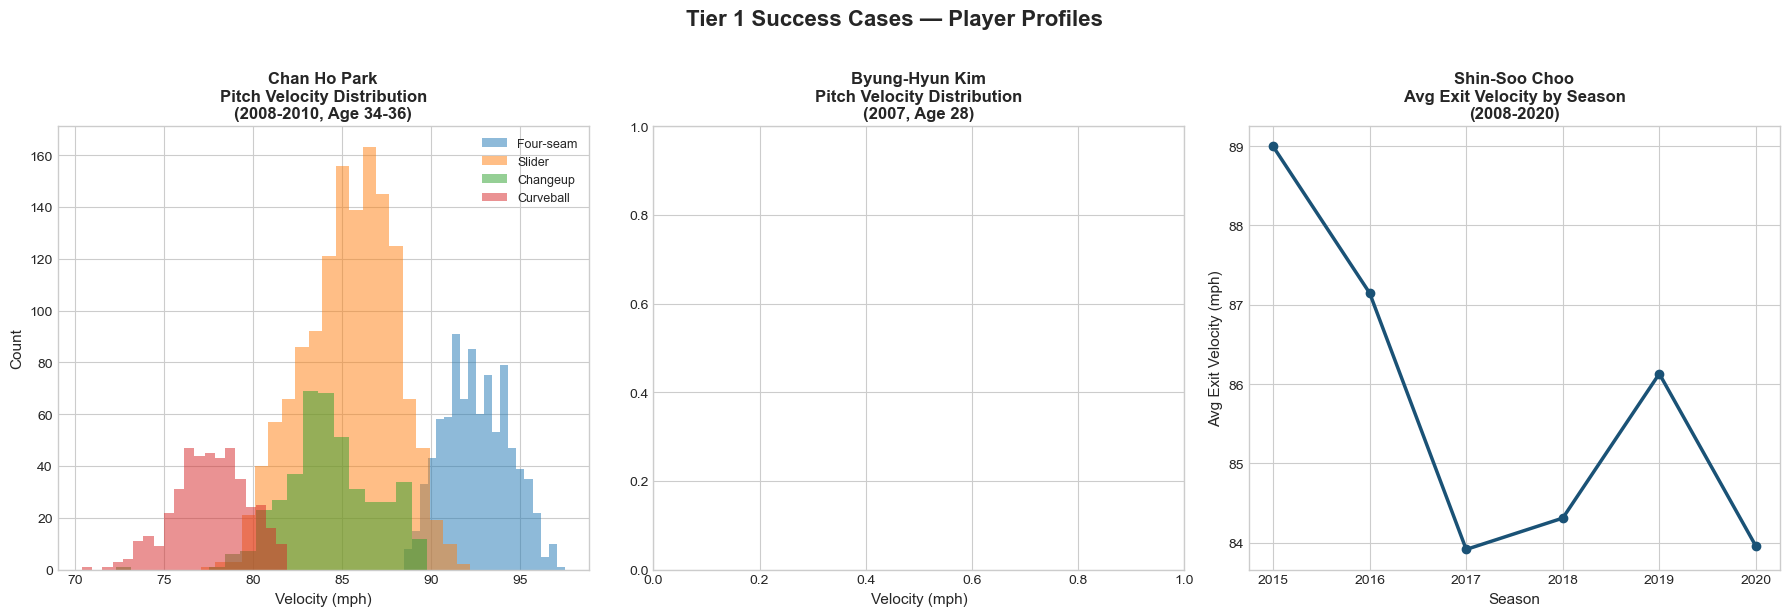

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pitch_names = {'FF': 'Four-seam', 'FT': 'Two-seam', 'SL': 'Slider', 
               'CH': 'Changeup', 'CU': 'Curveball', 'FC': 'Cutter'}

# 1. 박찬호 구종별 구속 분포
ax1 = axes[0]
for pitch_type in ['FF', 'SL', 'CH', 'CU']:
    data = park[park['pitch_type'] == pitch_type]['release_speed'].dropna()
    if len(data) > 10:
        ax1.hist(data, bins=20, alpha=0.5, label=pitch_names.get(pitch_type, pitch_type))

ax1.set_xlabel('Velocity (mph)', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Chan Ho Park\nPitch Velocity Distribution\n(2008-2010, Age 34-36)', 
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

# 2. 김병현 구종별 구속 분포
ax2 = axes[1]
for pitch_type in ['FF', 'SL', 'CH', 'CU', 'FC']:
    data = kim[kim['pitch_type'] == pitch_type]['release_speed'].dropna()
    if len(data) > 10:
        ax2.hist(data, bins=20, alpha=0.5, label=pitch_names.get(pitch_type, pitch_type))

ax2.set_xlabel('Velocity (mph)', fontsize=11)
ax2.set_title('Byung-Hyun Kim\nPitch Velocity Distribution\n(2007, Age 28)', 
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

# 3. 추신수 시즌별 exit velocity
ax3 = axes[2]
choo['season'] = pd.to_datetime(choo['game_date']).dt.year
choo_clean = choo.dropna(subset=['launch_speed'])
choo_by_season = choo_clean.groupby('season')['launch_speed'].mean()

ax3.plot(choo_by_season.index, choo_by_season.values, 
         color='#1a5276', linewidth=2.5, marker='o', markersize=6)
ax3.set_xlabel('Season', fontsize=11)
ax3.set_ylabel('Avg Exit Velocity (mph)', fontsize=11)
ax3.set_title('Shin-Soo Choo\nAvg Exit Velocity by Season\n(2008-2020)', 
              fontsize=12, fontweight='bold')

plt.suptitle('Tier 1 Success Cases — Player Profiles', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visualizations/05_tier1_player_profiles.png', dpi=150, bbox_inches='tight')
print("차트 저장 완료!")
plt.show()

차트 저장 완료!


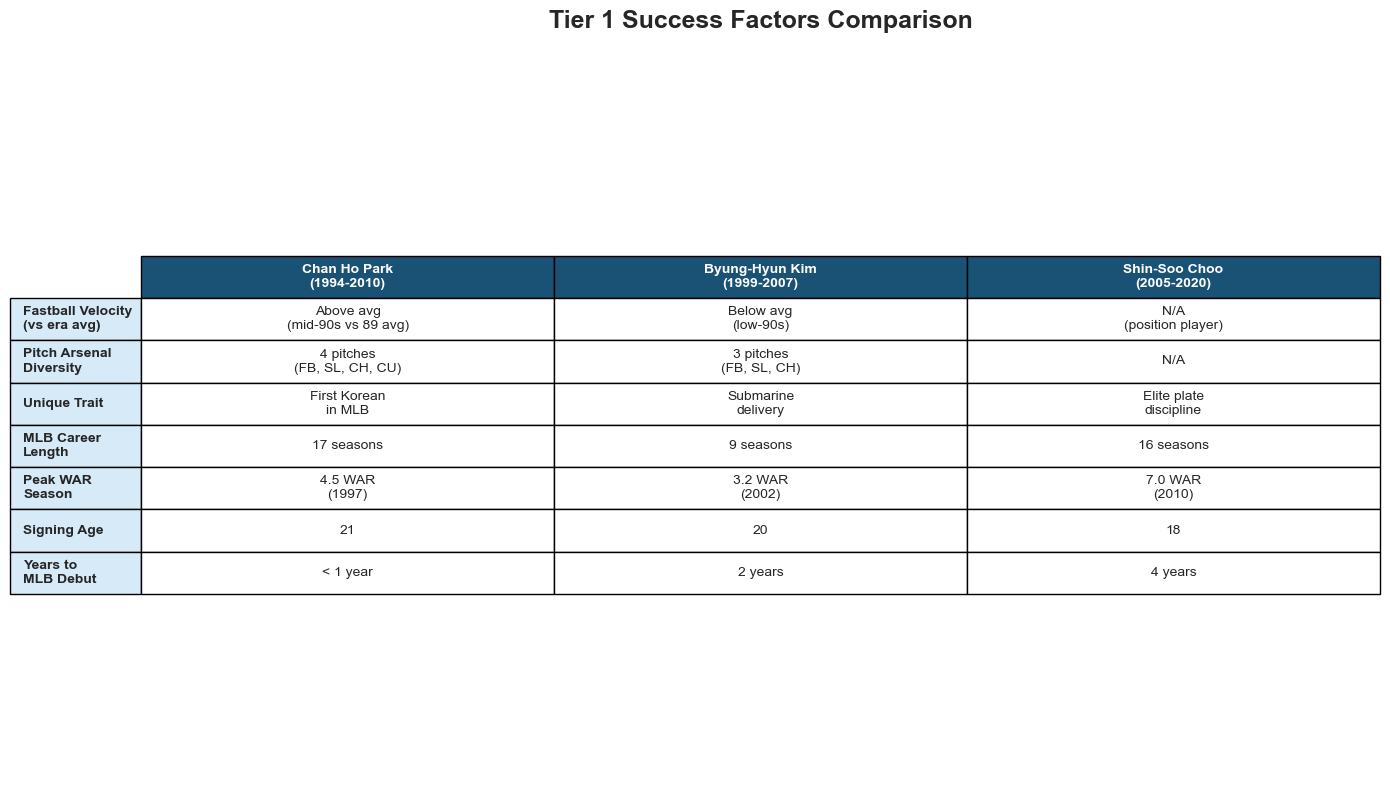

In [8]:
fig, ax = plt.subplots(figsize=(14, 8))

# 성공 요인 비교 테이블 시각화
factors = {
    'Factor': [
        'Fastball Velocity\n(vs era avg)',
        'Pitch Arsenal\nDiversity', 
        'Unique Trait',
        'MLB Career\nLength',
        'Peak WAR\nSeason',
        'Signing Age',
        'Years to\nMLB Debut'
    ],
    'Chan Ho Park\n(1994-2010)': [
        'Above avg\n(mid-90s vs 89 avg)',
        '4 pitches\n(FB, SL, CH, CU)',
        'First Korean\nin MLB',
        '17 seasons',
        '4.5 WAR\n(1997)',
        '21',
        '< 1 year'
    ],
    'Byung-Hyun Kim\n(1999-2007)': [
        'Below avg\n(low-90s)',
        '3 pitches\n(FB, SL, CH)',
        'Submarine\ndelivery',
        '9 seasons',
        '3.2 WAR\n(2002)',
        '20',
        '2 years'
    ],
    'Shin-Soo Choo\n(2005-2020)': [
        'N/A\n(position player)',
        'N/A',
        'Elite plate\ndiscipline',
        '16 seasons',
        '7.0 WAR\n(2010)',
        '18',
        '4 years'
    ]
}

# 테이블로 표시
cell_text = []
for i, factor in enumerate(factors['Factor']):
    cell_text.append([
        factors['Chan Ho Park\n(1994-2010)'][i],
        factors['Byung-Hyun Kim\n(1999-2007)'][i],
        factors['Shin-Soo Choo\n(2005-2020)'][i]
    ])

table = ax.table(
    cellText=cell_text,
    rowLabels=factors['Factor'],
    colLabels=['Chan Ho Park\n(1994-2010)', 'Byung-Hyun Kim\n(1999-2007)', 'Shin-Soo Choo\n(2005-2020)'],
    cellLoc='center',
    loc='center'
)

# 스타일링
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# 헤더 색상
for j in range(3):
    table[0, j].set_facecolor('#1a5276')
    table[0, j].set_text_props(color='white', fontweight='bold')

# 행 라벨 색상
for i in range(len(factors['Factor'])):
    table[i + 1, -1].set_facecolor('#d6eaf8')
    table[i + 1, -1].set_text_props(fontweight='bold')

ax.axis('off')
ax.set_title('Tier 1 Success Factors Comparison', 
             fontsize=18, fontweight='bold', pad=30)

plt.tight_layout()
plt.savefig('../visualizations/06_tier1_success_factors.png', dpi=150, bbox_inches='tight')
print("차트 저장 완료!")
plt.show()

## Tier 1 Analysis: What Made Them Successful?

### Chan Ho Park — The Pioneer Advantage
- Debuted when avg MLB fastball was ~89 mph. His mid-90s velocity was elite.
- First Korean MLB player created media attention and organizational investment.
- 4-pitch mix gave him versatility across different lineup constructions.
- **Lesson for Moon:** Being the "first" Korean signing for a franchise 
  (as Moon is for the Blue Jays) creates organizational commitment to development.

### Byung-Hyun Kim — The Deception Advantage  
- Below-average velocity but submarine delivery created natural deception.
- Thrived because batters had limited exposure to his arm slot.
- Short but intense peak (2001-2003 with Arizona).
- **Lesson for Moon:** Velocity alone does not determine success. 
  A unique trait that creates unfamiliarity can be equally valuable.

### Shin-Soo Choo — The Patient Development Path
- Took 4 years in the minors before establishing himself.
- Elite plate discipline (career 14.5% walk rate) was his differentiator.
- Longest career of any Korean amateur signing (16 seasons).
- **Lesson for Moon:** Patient, long-term development through the minor 
  leagues is the most proven path for Korean amateur signings.